In [5]:
pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
    --------------------------------------- 0.0/1.4 MB 262.6 kB/s eta 0:00:06
   - -------------------------------------- 0.0/1.4 MB 279.3 kB/s eta 0:00:05
   -- ------------------------------------- 0.1/1.4 MB 459.5 kB/s eta 0:00:03
   --- ------------------------------------ 0.1/1.4 MB 514.3 kB/s eta 0:00:03
   ------ --------------------------------- 0.2/1.4 MB 731.4 kB/s eta 0:00:02
   ------- -------------------------------- 0.3/1.4 MB 785.2 kB/s eta 0:00:02
   --------- ------------------------------ 0.3/1.4 MB 910.2 kB/s eta 0:00:02
   ---------- ----------------------------- 0.4/1.4 MB 882.8 kB/s eta 0:00:02
   ----------- ---------------------------- 0.4/1.4 MB 859.0 kB/s eta 0:00:02
   ---------------- ----------------------- 0.6/1.4 MB 1.1 MB/s eta 0:00:01
   ------------

In [ ]:
pip install apyori

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5974 sha256=e9df24f98edbc42fe5c53a8354bc08094fa383054c2e1e8e4baf39f3fed69cdc
  Stored in directory: c:\users\dell\appdata\local\pip\cache\wheels\77\3d\a6\d317a6fb32be58a602b1e8c6b5d6f31f79322da554cad2a5ea
Successfully built apyori


In [54]:
import pandas as pd
import mlxtend
from mlxtend.frequent_patterns import apriori, association_rules

In [55]:
df = pd.read_csv("dataset.csv")

In [56]:
df.head()

,memberNumber,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,1808,21-07-2015,candy
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   memberNumber     38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


In [58]:
df.shape

(38765, 3)

In [59]:
df.isnull().sum()

memberNumber       0
Date               0
itemDescription    0
dtype: int64

In [60]:
df.itemDescription.value_counts().head(10)

itemDescription
whole milk          2502
other vegetables    1898
rolls/buns          1715
soda                1514
yogurt              1334
root vegetables     1071
tropical fruit      1032
bottled water        933
sausage              924
citrus fruit         812
Name: count, dtype: int64

In [61]:
df['Year'] = pd.DatetimeIndex(df['Date']).year
df['Month'] = pd.DatetimeIndex(df['Date']).month
df['Day'] = pd.DatetimeIndex(df['Date']).day

In [62]:
df.head()

,memberNumber,Date,itemDescription,Year,Month,Day
0,1808,21-07-2015,tropical fruit,2015,7,21
1,1808,21-07-2015,candy,2015,7,21
2,2300,19-09-2015,pip fruit,2015,9,19
3,1187,12-12-2015,other vegetables,2015,12,12
4,3037,01-02-2015,whole milk,2015,1,2


In [63]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Top 10 selling products')

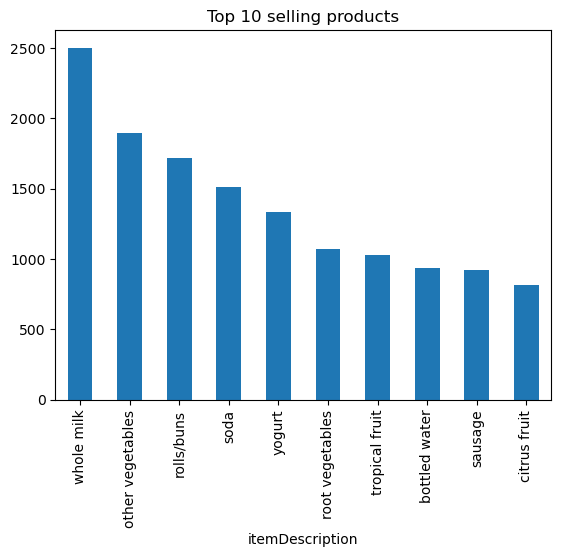

In [64]:
df.itemDescription.value_counts().head(10).plot.bar()
plt.title('Top 10 selling products')

In [65]:
df.itemDescription.value_counts().tail(10).sort_values()

itemDescription
kitchen utensil          1
preservation products    1
baby cosmetics           3
bags                     4
make up remover          5
toilet cleaner           5
frozen chicken           5
rubbing alcohol          5
salad dressing           6
whisky                   8
Name: count, dtype: int64

Text(0.5, 1.0, 'Top 10 least selling item')

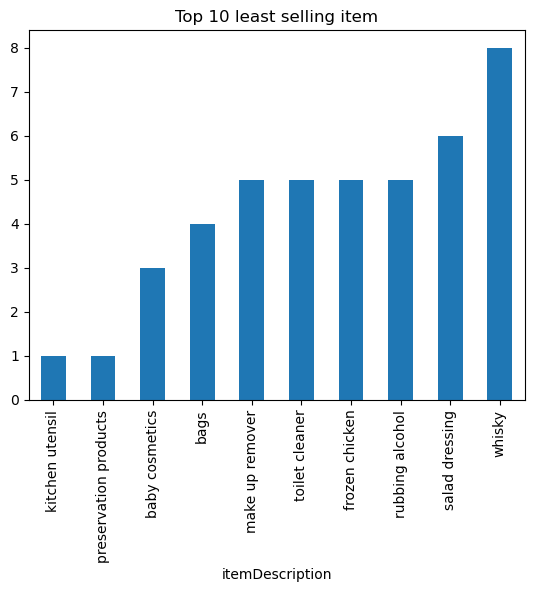

In [66]:
df.itemDescription.value_counts().tail(10).sort_values().plot.bar()
plt.title("Top 10 least selling item")

In [67]:
df.memberNumber.value_counts().head(10)

memberNumber
3180    36
2051    33
3050    33
3737    33
2271    31
3915    31
2625    31
2433    31
3872    30
4875    29
Name: count, dtype: int64

Text(0, 0.5, 'transctions')

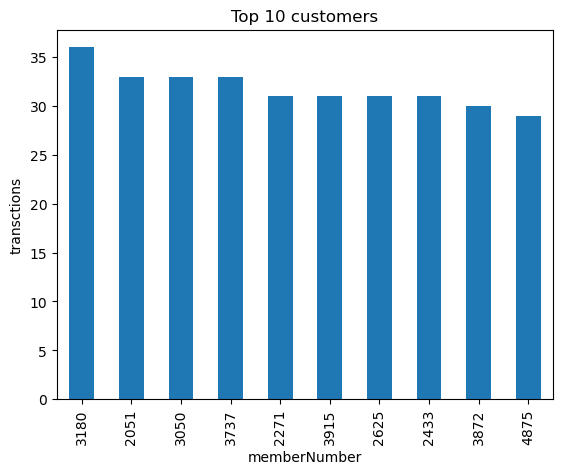

In [68]:
df.memberNumber.value_counts().head(10).plot.bar()
plt.title("Top 10 customers")
plt.ylabel("transctions")

In [69]:
df.Year.value_counts()

Year
2015    20488
2014    18277
Name: count, dtype: int64

In [70]:
df[df.Year == 2015]['Month'].value_counts().sort_index()

Month
1     1829
2     1485
3     1792
4     1666
5     1710
6     1791
7     1645
8     1963
9     1613
10    1663
11    1777
12    1554
Name: count, dtype: int64

In [71]:
data = df.copy()
data = pd.get_dummies(data['itemDescription'])
data.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [72]:
data = data.astype(int)

In [73]:
data.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [74]:
data1 = df.copy()
data1.drop(['itemDescription'],axis=1,inplace=True)
data1 = data1.join(data)

In [75]:
data1.head()

,memberNumber,Date,Year,Month,Day,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,1808,21-07-2015,2015,7,21,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1808,21-07-2015,2015,7,21,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2300,19-09-2015,2015,9,19,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1187,12-12-2015,2015,12,12,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,3037,01-02-2015,2015,1,2,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [76]:
products = df['itemDescription'].unique()
print(f"Number of products:- {len(products)}")

Number of products:- 167


In [77]:
products

array(['tropical fruit', 'candy', 'pip fruit', 'other vegetables',
       'whole milk', 'rolls/buns', 'pot plants', 'citrus fruit', 'beef',
       'frankfurter', 'chicken', 'butter', 'fruit/vegetable juice',
       'packaged fruit/vegetables', 'chocolate', 'specialty bar',
       'butter milk', 'bottled water', 'yogurt', 'sausage', 'brown bread',
       'hamburger meat', 'root vegetables', 'pork', 'pastry',
       'canned beer', 'berries', 'coffee', 'misc. beverages', 'ham',
       'turkey', 'curd cheese', 'red/blush wine',
       'frozen potato products', 'flour', 'sugar', 'frozen meals',
       'herbs', 'soda', 'detergent', 'grapes', 'processed cheese', 'fish',
       'sparkling wine', 'newspapers', 'curd', 'pasta', 'popcorn',
       'finished products', 'beverages', 'bottled beer', 'dessert',
       'dog food', 'specialty chocolate', 'condensed milk', 'cleaner',
       'white wine', 'meat', 'ice cream', 'hard cheese', 'cream cheese ',
       'liquor', 'pickled vegetables', 'liquor (

In [78]:
data2 = data1.groupby(['memberNumber','Date'])[products[:]].sum()

In [79]:
data.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [80]:
data2 = data2.reset_index()[products]

In [81]:
data2.head()

,tropical fruit,candy,pip fruit,other vegetables,whole milk,rolls/buns,pot plants,citrus fruit,beef,frankfurter,...,flower (seeds),rice,tea,salad dressing,specialty vegetables,pudding powder,ready soups,make up remover,toilet cleaner,preservation products
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [82]:
def naming(data):
    for i in products:
        if data[i]>0:
            data[i] = i
    return data

data2 = data2.apply(naming,axis=1)
data2.head()

C:\Users\dell\AppData\Local\Temp\ipykernel_26768\4260635251.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'whole milk' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  data[i] = i
C:\Users\dell\AppData\Local\Temp\ipykernel_26768\4260635251.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'canned beer' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  data[i] = i
C:\Users\dell\AppData\Local\Temp\ipykernel_26768\4260635251.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'sausage' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  data[i] = i
C:\Users\dell\AppData\Local\Temp\ipykernel_26768\4260635251.py:4: FutureWarning: Setting an item of incompatibl

,tropical fruit,candy,pip fruit,other vegetables,whole milk,rolls/buns,pot plants,citrus fruit,beef,frankfurter,...,flower (seeds),rice,tea,salad dressing,specialty vegetables,pudding powder,ready soups,make up remover,toilet cleaner,preservation products
0,0,0,0,0,whole milk,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,whole milk,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [85]:
newdata = data2.values
newdata

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=object)

In [86]:
newdata = [i[i!=0].tolist() for i in newdata if i[i!=0].tolist()]
newdata

[['whole milk', 'yogurt', 'sausage', 'semi-finished bread'],
 ['whole milk', 'pastry', 'salty snack'],
 ['canned beer', 'misc. beverages'],
 ['sausage', 'hygiene articles'],
 ['soda', 'pickled vegetables'],
 ['frankfurter', 'curd'],
 ['whole milk', 'rolls/buns', 'sausage'],
 ['whole milk', 'soda'],
 ['beef', 'white bread'],
 ['frankfurter', 'soda', 'whipped/sour cream'],
 ['other vegetables', 'frozen vegetables'],
 ['whole milk', 'butter'],
 ['tropical fruit', 'sugar'],
 ['butter milk', 'specialty chocolate'],
 ['rolls/buns', 'sausage'],
 ['root vegetables', 'detergent'],
 ['frozen meals', 'dental care'],
 ['rolls/buns'],
 ['dish cleaner', 'cling film/bags'],
 ['canned beer', 'frozen fish'],
 ['other vegetables', 'hygiene articles'],
 ['tropical fruit', 'pip fruit', 'whole milk'],
 ['rolls/buns', 'chocolate', 'red/blush wine'],
 ['other vegetables', 'shopping bags'],
 ['whole milk', 'rolls/buns', 'packaged fruit/vegetables', 'chocolate'],
 ['whole milk', 'root vegetables', 'pastry'],
 

In [93]:
from mlxtend.frequent_patterns import apriori
x = apriori(data, min_support=0.01,use_colnames=True)

c:\Users\dell\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [94]:
x

,support,itemsets
0,0.013311,(beef)
1,0.017722,(bottled beer)
2,0.024068,(bottled water)
3,0.014730,(brown bread)
4,0.013775,(butter)
5,0.018496,(canned beer)
6,0.010886,(chicken)
7,0.020947,(citrus fruit)
8,0.012279,(coffee)
9,0.013259,(curd)


In [95]:
from apyori import apriori
association = apriori(newdata, min_support = 0.02,min_confidence = 0.01, max_length=3,min_lift=3)

In [96]:
result = list(association)
result

[]